# Forecasting the exports volume of processed seafood in Thailand

## 1. Importing Required Libraries
In this cell, we load all the necessary Python libraries used for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning model creation and evaluation (`scikit-learn`).

In [1]:
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Importing machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

## 2. Convert Excel File to CSV 
This script loads an Excel file using the `pandas` library and converts it to a CSV file.

It uses UTF-8 with BOM encoding to ensure compatibility with Excel and excludes the index column from the output.

In [2]:
# Load the .xlsx file (default sheet)
df = pd.read_excel('DATA/Export 2007-2024.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Save as .csv
df.to_csv('DATA/Export 2007-2024.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

## 2. Data Loading, Cleaning, and Feature Engineering
In this section, we prepare the export dataset for modeling. The process includes:
- Loading the CSV file containing monthly seafood export records from 2007 to 2024.
- Creating a datetime column by combining the Year and Month columns, enabling proper chronological sorting and time-based analysis.
- Filtering the dataset by removing rows where all product-related quantities and values are equal to zero, as these records likely represent missing or irrelevant data.
- Sorting the dataset by date to preserve temporal order.
- Generating a numerical time feature called month_num, which represents the number of months elapsed since the beginning of the dataset. This variable is used as the main input for forecasting models.

In [3]:
# Load the CSV file
df = pd.read_csv("DATA/Export 2007-2024.csv")

# Create a datetime column from year and month
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))

# Function to remove rows where all specified columns have a value of 0.0
def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

df = supprimer_lignes_tous_zero_colonnes(df, [
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
    'Dried Shrimp Quantity (Tons)',
    'Dried Shrimp Value (Million Baht)',
    'Boiled or Steamed Shrimp Quantity (Tons)',
    'Boiled or Steamed Shrimp Value (Million Baht)',
    'Shrimp in Airtight Containers Quantity (Tons)',
    'Shrimp in Airtight Containers Value (Million Baht)',
    'Preserved or Processed Shrimp Quantity (Tons)',
    'Preserved or Processed Shrimp Value (Million Baht)',
    'Shrimp Quantity (Tons)',
    'Shrimp Value (Million Baht)',
    'Chilled/Frozen Fresh Squid Quantity (Tons)',
    'Chilled/Frozen Fresh Squid Value (Million Baht)',
    'Dried Squid Quantity (Tons)',
    'Dried Squid Value (Million Baht)',
    'Processed or Preserved Squid Quantity (Tons)',
    'Processed or Preserved Squid Value (Million Baht)',
    'Smoked squid Quantity (Tons)',
    'Smoked squid Value (Million Baht)',
    'Squid Quantity (Tons)',
    'Squid Value (Million Baht)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
    'Chilled/Frozen Fish Fillets Quantity (Tons)',
    'Chilled/Frozen Fish Fillets Value (Million Baht)',
    'Dried Fish Quantity (Tons)',
    'Dried Fish Value (Million Baht)',
    'Live Fish and Fish Breeding Stock Quantity (Tons)',
    'Live Fish and Fish Breeding Stock Value (Million Baht)',
    'Fish Quantity (Tons)',
    'Fish Value (Million Baht)',
    'Canned Tuna Quantity (Tons)',
    'Canned Tuna Value (Million Baht)',
    'Canned Sardines Quantity (Tons)',
    'Canned Sardines Value (Million Baht)',
    'Other Canned Fish Quantity (Tons)',
    'Other Canned Fish Value (Million Baht)',
    'Canned Crab Quantity (Tons)',
    'Canned Crab Value (Million Baht)',
    'Other Canned Seafood Quantity (Tons)',
    'Other Canned Seafood Value (Million Baht)',
    'Canned Products Quantity (Tons)',
    'Canned Products Value (Million Baht)',
    'Canned Dog and Cat Food Quantity (Tons)',
    'Canned Dog and Cat Food Value (Million Baht)',
    'Processed Seafood Products Quantity (Tons)',
    'Processed Seafood Products Value (Million Baht)',
    'Processed Tuna Products Quantity (Tons)',
    'Processed Tuna Products Value (Million Baht)',
    'Preserved or Processed Crab Quantity (Tons)',
    'Preserved or Processed Crab Value (Million Baht)',
    'Other Processed Seafood Products Quantity (Tons)',
    'Other Processed Seafood Products Value (Million Baht)',
    'Other Fishery Products Quantity (Tons)',
    'Other Fishery Products Value (Million Baht)',
    'Grand Total Quantity (Tons)',
    'Grand Total Value (Million Baht)'])

# Sort the dataset by month
df = df.sort_values('month')

# Create a numerical time feature (number of months since start)
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')

## 3. Models

### 3.1 Model Selection

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 3.2 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

In [4]:
# Cross-validation setup
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### 3.3 Model Evaluation Methodology

In this section, we implement a comparative analysis of several machine learning models to forecast Thailand’s monthly seafood export volume. The methodology consists of the following steps:

- **Data Preparation**:
We use cleaned and time-encoded data including a numerical time index and cyclical features (month sine and cosine) to capture seasonality.

- **Validation Strategy**:
A TimeSeriesSplit with 5 folds is used to respect the chronological order of the data during training and evaluation.

- **Performance Metrics**:
For each model and fold, we compute:

    - Root Mean Squared Error (RMSE)

    - R² Score (Coefficient of Determination)
Average and standard deviation values are calculated to assess both accuracy and consistency

- **Visualization**:

    - For the last fold of each model, a scatter plot is generated comparing actual vs. predicted values.

    - A final forecasting plot displays each model’s predicted export volume from the start of the dataset up to 2030, along with the actual historical data for comparison.

This approach allows us to identify which model best captures the trends and seasonal behavior in export quantities, while also testing their generalization capability beyond the observed data.

### 3.4 Applying the Models


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


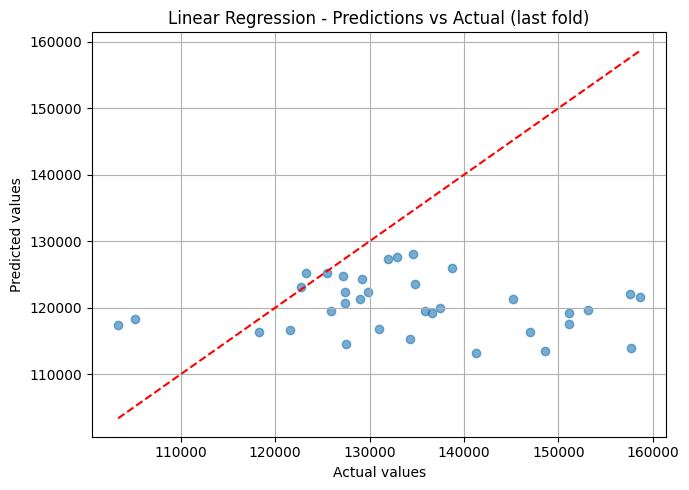


=== SVR ===

--- Fold 1 ---
RMSE: 14754.6254
R²: -0.0687

--- Fold 2 ---
RMSE: 21046.1845
R²: -3.0512

--- Fold 3 ---
RMSE: 28340.8471
R²: -4.9767

--- Fold 4 ---
RMSE: 20275.5112
R²: -2.9318

--- Fold 5 ---
RMSE: 16660.2716
R²: -0.5956


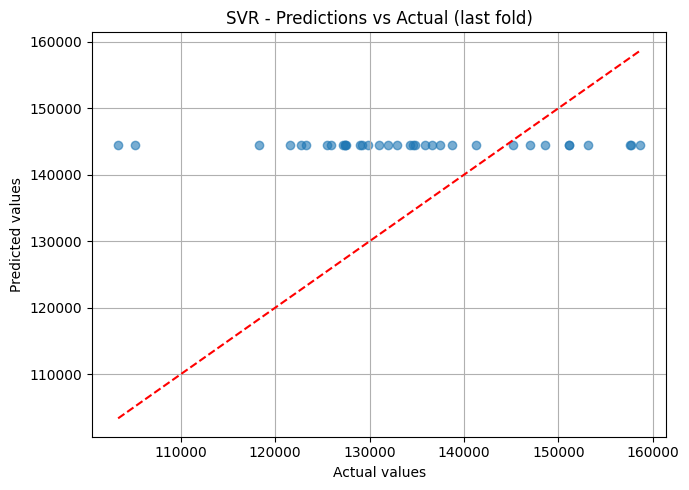


=== Decision Tree ===

--- Fold 1 ---
RMSE: 13157.3056
R²: 0.1501

--- Fold 2 ---
RMSE: 26085.3913
R²: -5.2235

--- Fold 3 ---
RMSE: 13636.5714
R²: -0.3837

--- Fold 4 ---
RMSE: 11038.2821
R²: -0.1653

--- Fold 5 ---
RMSE: 14294.9379
R²: -0.1747


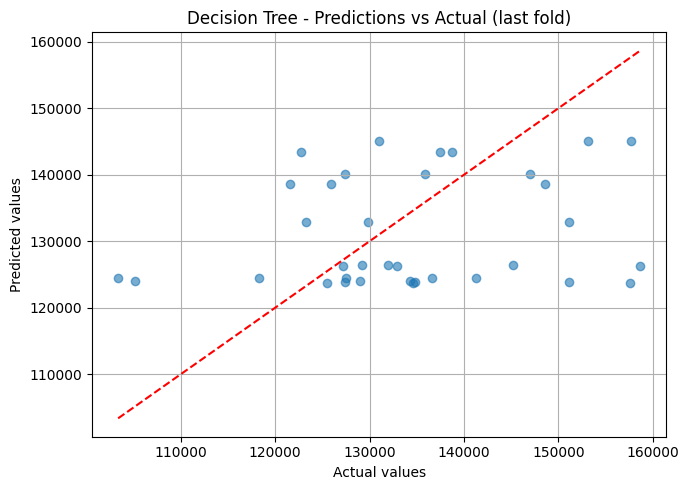


=== Random Forest ===

--- Fold 1 ---
RMSE: 12196.0714
R²: 0.2698

--- Fold 2 ---
RMSE: 18719.3601
R²: -2.2049

--- Fold 3 ---
RMSE: 11743.6145
R²: -0.0262

--- Fold 4 ---
RMSE: 11047.5942
R²: -0.1673

--- Fold 5 ---
RMSE: 12451.6732
R²: 0.1087


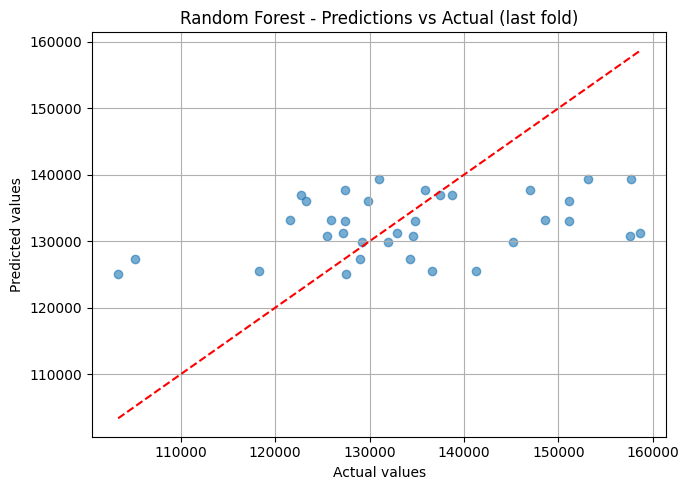


=== KNN ===

--- Fold 1 ---
RMSE: 14292.2445
R²: -0.0028

--- Fold 2 ---
RMSE: 15791.6621
R²: -1.2808

--- Fold 3 ---
RMSE: 13956.2199
R²: -0.4493

--- Fold 4 ---
RMSE: 11065.9176
R²: -0.1712

--- Fold 5 ---
RMSE: 13313.3142
R²: -0.0189


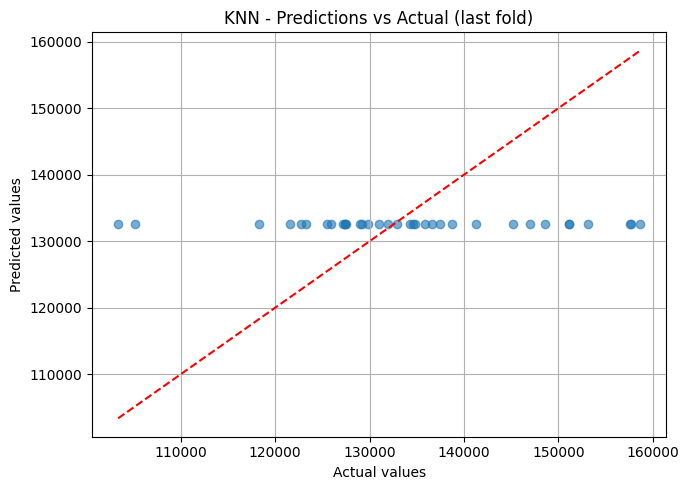


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20215.4880  4672.8087  -2.3248  1.7893
Decision Tree      15642.4976  5334.2041  -1.1594  2.0392
Random Forest      13231.6627  2784.9631  -0.4040  0.9120
KNN                13683.8717  1541.3026  -0.3846  0.4759


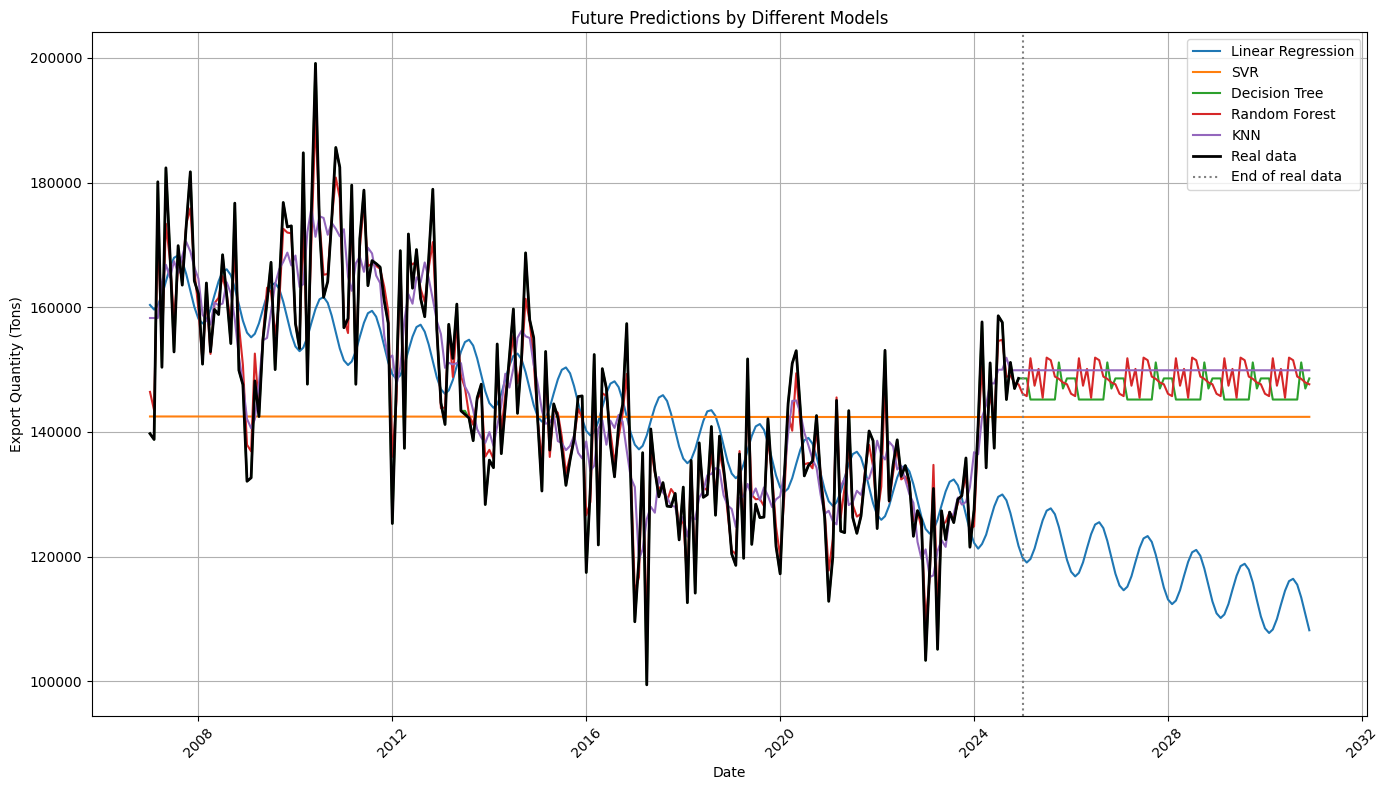

In [5]:
# --- Data loading and preprocessing ---

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Cyclical variables to handle seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Models to evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot predictions vs actual values for the last fold
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of results ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Future prediction using all available data ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})


plt.figure(figsize=(14, 8))

# Retrain model on the entire dataset
for name, model in models.items():
    
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning 
In this section, we re-evaluate the five machine learning models using hyperparameter optimization to improve their performance.

### 4.1  Grid Search Hyperparameter Tuning for Regression Models

The goal is to determine the best combination of hyperparameters for each model using grid search combined with time series cross-validation `(TimeSeriesSplit)`, which ensures that the temporal order of the data is respected during training and validation.

**Key elements of this process:**
- A hyperparameter grid is defined for each model (except Linear Regression, which has no tunable hyperparameters).

- For each model, GridSearchCV tests all combinations of hyperparameters using 5-fold time series CV and evaluates them based on negative mean squared error.

- The best-performing model configuration (lowest RMSE) is saved for each algorithm.

- A summary table is printed showing:

    - The best hyperparameter set (Best Params)

    - The corresponding cross-validated RMSE (Best CV RMSE)

This tuning step aims to maximize the predictive accuracy of each model before proceeding to final evaluations and future forecasting.

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter search spaces for each model
param_grids = {
    "Linear Regression": {},  # No hyperparameters to tune here
    
    "SVR": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1, 0.5]
    },
    
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    
    "KNN": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
    }
}

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

best_models = {}
results = {}

for name, model in models.items():
    print(f"\n=== Hyperparameter tuning for {name} ===")
    
    param_grid = param_grids.get(name, {})
    
    # If there are no hyperparameters, skip the search
    if not param_grid:
        print("No hyperparameters to tune for this model.")
        model.fit(X, y)
        best_models[name] = model
        continue
    
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    best_models[name] = grid_search.best_estimator_
    
    best_rmse = (-grid_search.best_score_) ** 0.5
    
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    
    results[name] = {
        "Best Params": grid_search.best_params_,
        "Best CV RMSE": best_rmse
    }

# Summary display
import pandas as pd
summary_df = pd.DataFrame(results).T
print("\n=== Summary of Hyperparameter Tuning Results ===")
print(summary_df)


=== Hyperparameter tuning for Linear Regression ===
No hyperparameters to tune for this model.

=== Hyperparameter tuning for SVR ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for SVR: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV RMSE: 20590.6514

=== Hyperparameter tuning for Decision Tree ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE: 13921.7242

=== Hyperparameter tuning for Random Forest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 13357.0428

=== Hyperparameter tuning for KNN ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best CV RMSE: 13054.7777

=== Summary of Hyperparameter 

### 4.2  Evaluation of Optimized Models and Long-Term Forecasting

In this section, we re-evaluate all five machine learning models using their best hyperparameter configurations, obtained previously through grid search. Each model is validated using a 5-fold time series cross-validation to compute its predictive accuracy and stability.

**Methodology**:
- We use the same input features (month_num, month_sin, month_cos) and target (Grand Total Quantity (Tons)).

- For each model:

    - The model is trained and evaluated across 5 consecutive folds.

    - Performance metrics include: RMSE (Root Mean Squared Error) and R² Score (Coefficient of Determination)

    - A scatter plot is generated for the final fold, comparing actual vs. predicted values.

- A summary table of average performance is printed for model comparison.

- Finally, all models are re-trained on the full dataset and used to forecast seafood export volumes up to *December 2030*.

The results are visualized in a single plot showing each model's predicted trend alongside the historical data.

This step highlights how the tuned models perform under realistic, temporally ordered validation, and assesses their ability to extrapolate future export trends.


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


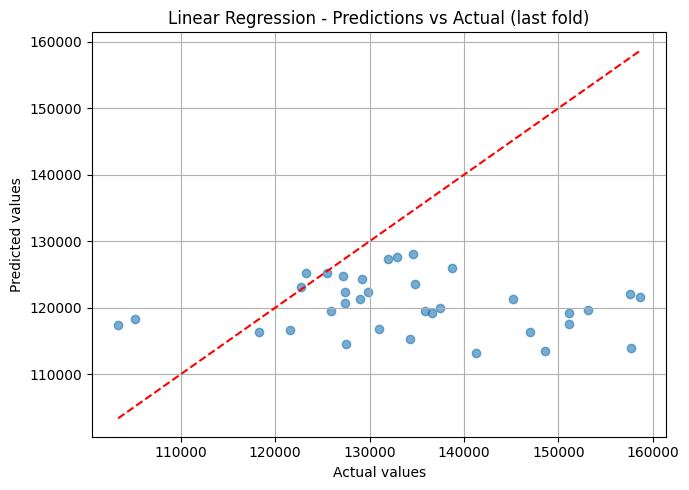


=== SVR ===

--- Fold 1 ---
RMSE: 14754.5118
R²: -0.0687

--- Fold 2 ---
RMSE: 21051.6542
R²: -3.0533

--- Fold 3 ---
RMSE: 28183.5888
R²: -4.9105

--- Fold 4 ---
RMSE: 19837.8669
R²: -2.7639

--- Fold 5 ---
RMSE: 16466.6702
R²: -0.5587


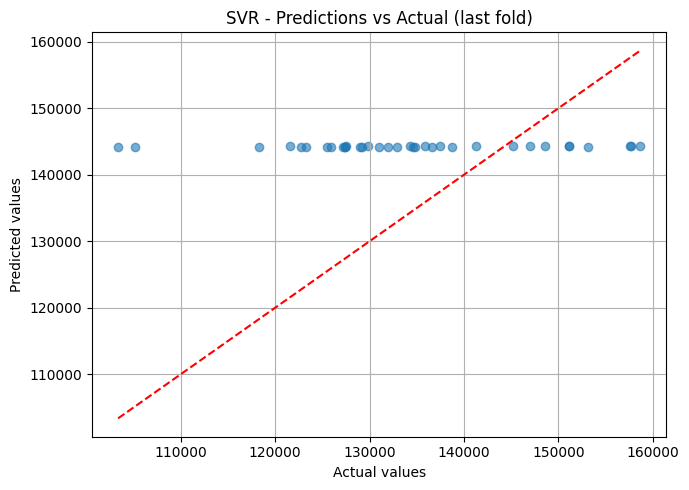


=== Decision Tree ===

--- Fold 1 ---
RMSE: 11500.9926
R²: 0.3506

--- Fold 2 ---
RMSE: 18124.6197
R²: -2.0045

--- Fold 3 ---
RMSE: 14284.2584
R²: -0.5183

--- Fold 4 ---
RMSE: 12154.4430
R²: -0.4129

--- Fold 5 ---
RMSE: 12511.0683
R²: 0.1002


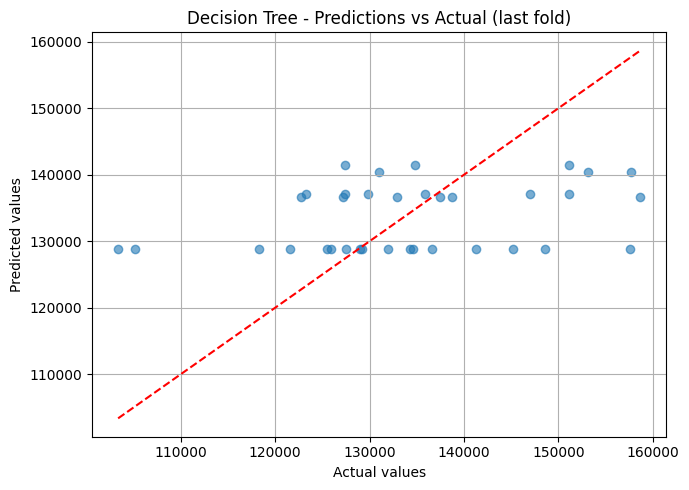


=== Random Forest ===

--- Fold 1 ---
RMSE: 11685.2024
R²: 0.3297

--- Fold 2 ---
RMSE: 18554.8977
R²: -2.1489

--- Fold 3 ---
RMSE: 11408.9512
R²: 0.0314

--- Fold 4 ---
RMSE: 11075.8590
R²: -0.1733

--- Fold 5 ---
RMSE: 12403.9873
R²: 0.1155


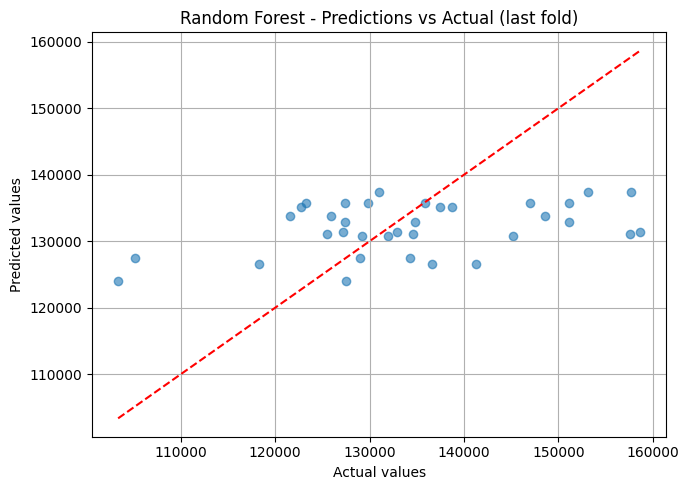


=== KNN ===

--- Fold 1 ---
RMSE: 14421.3840
R²: -0.0210

--- Fold 2 ---
RMSE: 11139.6225
R²: -0.1350

--- Fold 3 ---
RMSE: 11959.5515
R²: -0.0643

--- Fold 4 ---
RMSE: 14250.4425
R²: -0.9422

--- Fold 5 ---
RMSE: 13189.4890
R²: -0.0000


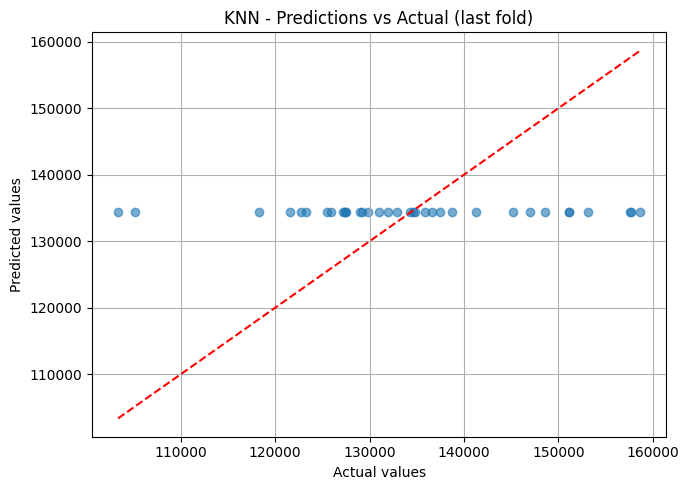


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20058.8584  4649.4222  -2.2710  1.7666
Decision Tree      13715.0764  2389.7874  -0.4970  0.8192
Random Forest      13025.7795  2798.9728  -0.3691  0.9044
KNN                12992.0979  1277.7379  -0.2325  0.3579


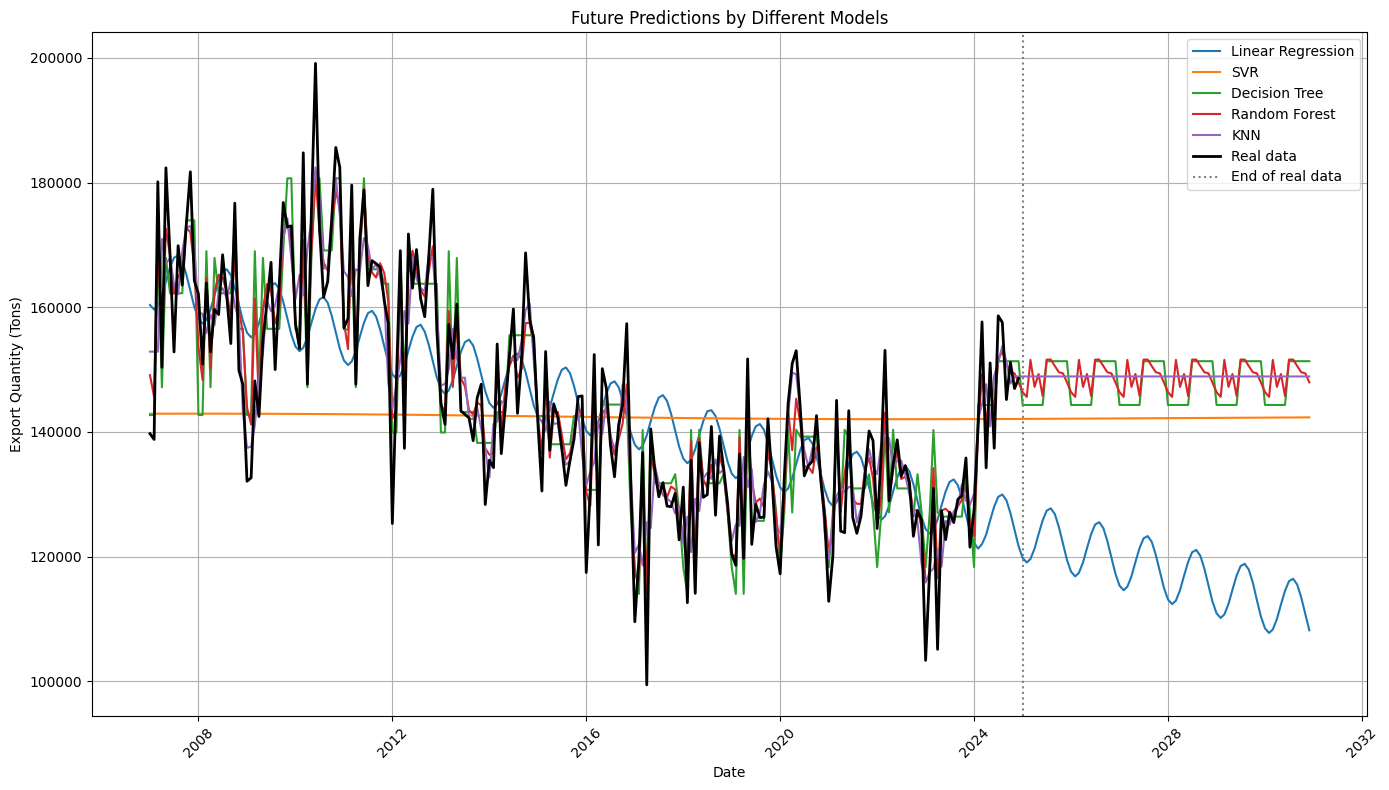

In [7]:
# --- Data Loading and Preparation ---

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Cyclical variables to capture seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Models to Evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(C= 10, epsilon= 0.01, gamma= 'scale'),
    "Decision Tree": DecisionTreeRegressor(max_depth= 10, min_samples_leaf= 4, min_samples_split= 10),
    "Random Forest": RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200),
    "KNN": KNeighborsRegressor(n_neighbors= 3, p= 1, weights= 'uniform')
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot last fold predictions
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of Results ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Future Prediction on the Complete Timeline ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})

plt.figure(figsize=(14, 8))

# Retrain model on the full dataset
for name, model in models.items():

    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Final Forecast Using Random Forest with All Product Features

In this section, we build a comprehensive forecasting model using Random Forest Regressor with both temporal features and product-specific export quantities as inputs. The objective is to improve the accuracy of total export volume predictions (Grand Total Quantity (Tons)) by integrating historical patterns from multiple seafood categories.

### 5.1 Random Forest with Full Feature Set

In this block, we train and evaluate a Random Forest Regressor using a rich set of features that combine temporal indicators and historical export volumes for all major seafood product categories.

**Workflow:**
- The input matrix `X` includes:

    - Time-based features: `month_num`, `month_sin`, `month_cos`

    - Export quantities for 25 specific product categories (e.g., shrimp, fish, canned products).

- The target `y` is the total export quantity `(Grand Total Quantity (Tons))`.

- We evaluate the model using 5-fold time series cross-validation, computing the average and standard deviation of RMSE.

- After cross-validation, the model is retrained on the entire dataset to prepare for future forecasting.

This approach aims to improve the prediction of total seafood exports by leveraging trends observed in individual product lines.

In [8]:
# Prepare date column
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')

# Add temporal variables
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

# Features + cible
X = df[['month_num', 'month_sin', 'month_cos']]

# Model

based_model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

model_Chilled_Frozen_Fresh_Shrimp = based_model
model_Shrimp_Airtight = based_model
model_Preserved_Processed_Shrimp= based_model
model_Shrimp= based_model
model_Chilled_Frozen_Fresh_Squid= based_model
model_Dried_Squid= based_model
model_Processed_Preserved_Squid= based_model
model_Squid= based_model
model_Chilled_Frozen_Fresh_Fish= based_model
model_Chilled_Frozen_Fish_Fillets= based_model
model_Dried_Fish= based_model
model_Live_Fish_Fish_Breeding_Stock= based_model
model_Fish= based_model
model_Canned_Tuna= based_model
model_Canned_Sardines= based_model
model_Other_Canned_Fish= based_model
model_Canned_Crab= based_model
model_Other_Canned_Seafood= based_model
model_Canned_Products= based_model
model_Canned_Dog_Cat_Food= based_model
model_Processed_Seafood_Products= based_model
model_Processed_Tuna_Products= based_model
model_Preserved_Processed_Crab= based_model
model_Other_Processed_Seafood_Products= based_model
model_Other_Fishery_Products= based_model

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

# ---------- scenario for 2025 ----------
# Create range
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)
mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]

# Dataframe creation for complete prediction
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

def prediction(model,y):
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        rmse_scores.append(rmse)


    model.fit(X, y)

    y_all_pred = model.predict(X_all)

    return y_all_pred

prediction_chilled_Shrimp = prediction(model_Chilled_Frozen_Fresh_Shrimp, df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'].values)
prediction_Shrimp_Airtight = prediction(model_Shrimp_Airtight, df['Shrimp in Airtight Containers Quantity (Tons)'].values)
prediction_Shrimp_Processed = prediction(model_Preserved_Processed_Shrimp, df['Preserved or Processed Shrimp Quantity (Tons)'].values)
prediction_Shrimp = prediction(model_Shrimp,df['Shrimp Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Squid = prediction(model_Chilled_Frozen_Fresh_Squid, df['Chilled/Frozen Fresh Squid Quantity (Tons)'].values)
prediction_Dried_Squid = prediction(model_Dried_Squid, df['Dried Squid Quantity (Tons)'].values)
prediction_Processed_Preserved_Squid = prediction(model_Processed_Preserved_Squid, df['Processed or Preserved Squid Quantity (Tons)'].values)
prediction_Squid = prediction(model_Squid, df['Squid Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Fish = prediction(model_Chilled_Frozen_Fresh_Fish, df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fish_Fillets = prediction(model_Chilled_Frozen_Fish_Fillets, df['Chilled/Frozen Fish Fillets Quantity (Tons)'].values)
prediction_Dried_Fish = prediction(model_Dried_Fish, df['Dried Fish Quantity (Tons)'].values)
prediction_Live_Fish_Fish_Breeding_Stock = prediction(model_Live_Fish_Fish_Breeding_Stock, df['Dried Fish Quantity (Tons)'].values)
prediction_Fish = prediction(model_Fish,df['Fish Quantity (Tons)'].values)
prediction_Canned_Tuna = prediction(model_Canned_Tuna,df['Canned Tuna Quantity (Tons)'].values)
prediction_Canned_Sardines = prediction(model_Canned_Sardines,df['Canned Sardines Quantity (Tons)'].values)
prediction_Other_Canned_Fish = prediction(model_Other_Canned_Fish,df['Other Canned Fish Quantity (Tons)'].values)
prediction_Canned_Crab = prediction(model_Canned_Crab,df['Canned Crab Quantity (Tons)'].values)
prediction_Other_Canned_Seafood = prediction(model_Other_Canned_Seafood,df['Other Canned Seafood Quantity (Tons)'].values)
prediction_Canned_Products = prediction(model_Canned_Products,df['Canned Products Quantity (Tons)'].values)
prediction_Canned_Dog_Cat_Food = prediction(model_Canned_Dog_Cat_Food,df['Canned Dog and Cat Food Quantity (Tons)'].values)
prediction_Processed_Seafood_Products = prediction(model_Processed_Seafood_Products,df['Processed Seafood Products Quantity (Tons)'].values)
prediction_Processed_Tuna_Products = prediction(model_Processed_Tuna_Products,df['Processed Tuna Products Quantity (Tons)'].values)
prediction_Preserved_Processed_Crab  = prediction(model_Preserved_Processed_Crab,df['Preserved or Processed Crab Quantity (Tons)'].values)
prediction_Other_Processed_Seafood_Products  = prediction(model_Other_Processed_Seafood_Products,df['Other Processed Seafood Products Quantity (Tons)'].values)
prediction_Other_Fishery_Products = prediction(model_Other_Fishery_Products,df['Other Fishery Products Quantity (Tons)'].values)

X_Future = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)':prediction_chilled_Shrimp,
    'Shrimp in Airtight Containers Quantity (Tons)':prediction_Shrimp_Airtight,
    'Preserved or Processed Shrimp Quantity (Tons)':prediction_Shrimp_Processed,
    'Shrimp Quantity (Tons)':prediction_Shrimp,
    'Chilled/Frozen Fresh Squid Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Squid,
    'Dried Squid Quantity (Tons)':prediction_Dried_Squid,
    'Processed or Preserved Squid Quantity (Tons)':prediction_Processed_Preserved_Squid,
    'Squid Quantity (Tons)':prediction_Squid,
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Fish,
    'Chilled/Frozen Fish Fillets Quantity (Tons)':prediction_Chilled_Frozen_Fish_Fillets,
    'Dried Fish Quantity (Tons)':prediction_Dried_Fish,
    'Live Fish and Fish Breeding Stock Quantity (Tons)':prediction_Live_Fish_Fish_Breeding_Stock,
    'Fish Quantity (Tons)':prediction_Fish,
    'Canned Tuna Quantity (Tons)':prediction_Canned_Tuna,
    'Canned Sardines Quantity (Tons)':prediction_Canned_Sardines,
    'Other Canned Fish Quantity (Tons)':prediction_Other_Canned_Fish,
    'Canned Crab Quantity (Tons)':prediction_Canned_Crab,
    'Other Canned Seafood Quantity (Tons)':prediction_Other_Canned_Seafood,
    'Canned Products Quantity (Tons)':prediction_Canned_Products,
    'Canned Dog and Cat Food Quantity (Tons)':prediction_Canned_Dog_Cat_Food,
    'Processed Seafood Products Quantity (Tons)':prediction_Processed_Seafood_Products,
    'Processed Tuna Products Quantity (Tons)':prediction_Processed_Tuna_Products,
    'Preserved or Processed Crab Quantity (Tons)':prediction_Preserved_Processed_Crab ,
    'Other Processed Seafood Products Quantity (Tons)':prediction_Other_Processed_Seafood_Products ,
    'Other Fishery Products Quantity (Tons)':prediction_Other_Fishery_Products
})

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

RMSE CV: Moyenne = 1959.03, Écart-type = 2212.39


### 5.2 Forecasting Total Exports with Predicted Category-Level Inputs

In this block, we use the trained Random Forest model to forecast total export quantities up to December 2025, using the predicted values of each product category as inputs.

**Key steps:**
- Future months from the dataset start until end of 2025 are generated and encoded as temporal features (`month_num`, `month_sin`, `month_cos`).

- Forecast inputs are taken from the previously built `X_Future` dataset, which includes predicted export quantities for each product type.

- The model predicts the total export volume (`y_all_pred`) based on these inputs.

- A final line plot shows:

    - Historical data in blue dashed line.

    - Forecasted total exports in green dashed line.

    - A vertical marker at *December 2024*, which separates observed and forecasted periods.

This visualization provides a forward-looking estimate of how Thailand’s total seafood exports might evolve under current trends across individual product segments.

RMSE CV: Moyenne = 9574.43, Écart-type = 1821.19


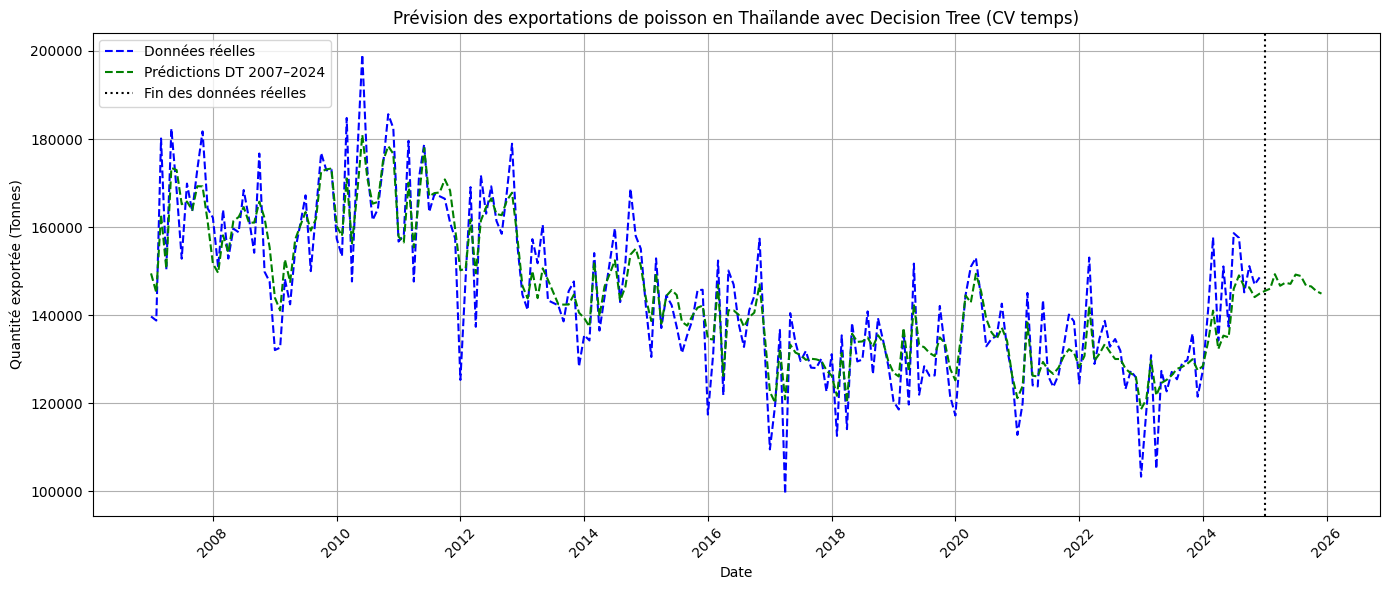

In [9]:
# features and target
X = df[['month_num', 'month_sin', 'month_cos', 
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
        'Shrimp in Airtight Containers Quantity (Tons)',
        'Preserved or Processed Shrimp Quantity (Tons)',
        'Shrimp Quantity (Tons)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)',
        'Dried Squid Quantity (Tons)',
        'Processed or Preserved Squid Quantity (Tons)',
        'Squid Quantity (Tons)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)',
        'Dried Fish Quantity (Tons)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)',
        'Fish Quantity (Tons)',
        'Canned Tuna Quantity (Tons)',
        'Canned Sardines Quantity (Tons)',
        'Other Canned Fish Quantity (Tons)',
        'Canned Crab Quantity (Tons)',
        'Other Canned Seafood Quantity (Tons)',
        'Canned Products Quantity (Tons)',
        'Canned Dog and Cat Food Quantity (Tons)',
        'Processed Seafood Products Quantity (Tons)',
        'Processed Tuna Products Quantity (Tons)',
        'Preserved or Processed Crab Quantity (Tons)',
        'Other Processed Seafood Products Quantity (Tons)',
        'Other Fishery Products Quantity (Tons)',
        ]]
y = df['Grand Total Quantity (Tons)'].values

# DecisionTree
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Training
model.fit(X, y)

# Months generation to 2025-12
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


# Forecasting
y_all_pred = model.predict(X_Future)

# Display
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Decision Tree (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# PARIE 6

Début de la Partie 6 : Application de LSTM
Utilisation du DataFrame 'df' existant.
La colonne 'value' n'a pas été trouvée dans le DataFrame existant. Veuillez l'adapter ou renommer votre colonne de série temporelle.
Données synthétiques utilisées pour l'exemple.
Forme de X_train: (719, 100, 1)
Forme de y_train: (719,)
Forme de X_test: (180, 100, 1)
Forme de y_test: (180,)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
           

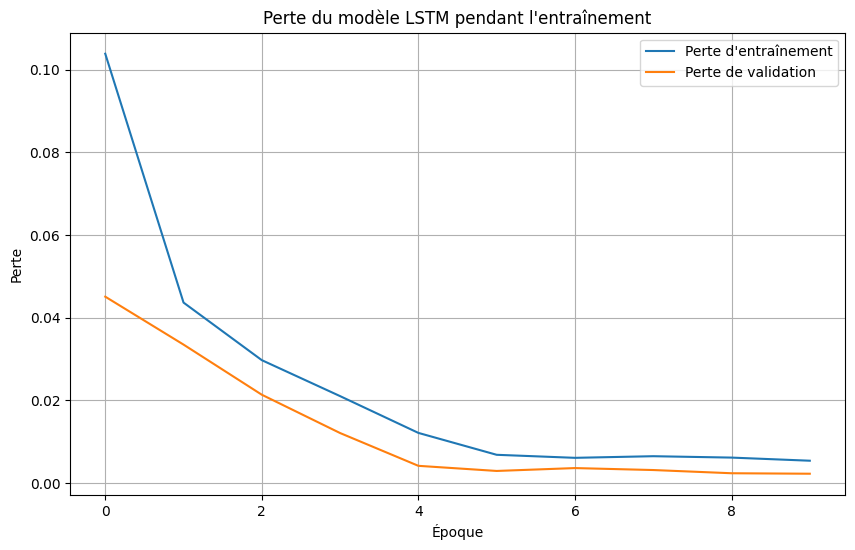


Réalisation de prédictions sur l'ensemble de test...
6/6 [==============================] - 0s 13ms/step

RMSE (entraînement): 0.1148
MAE (entraînement): 0.0925
RMSE (test): 0.0933


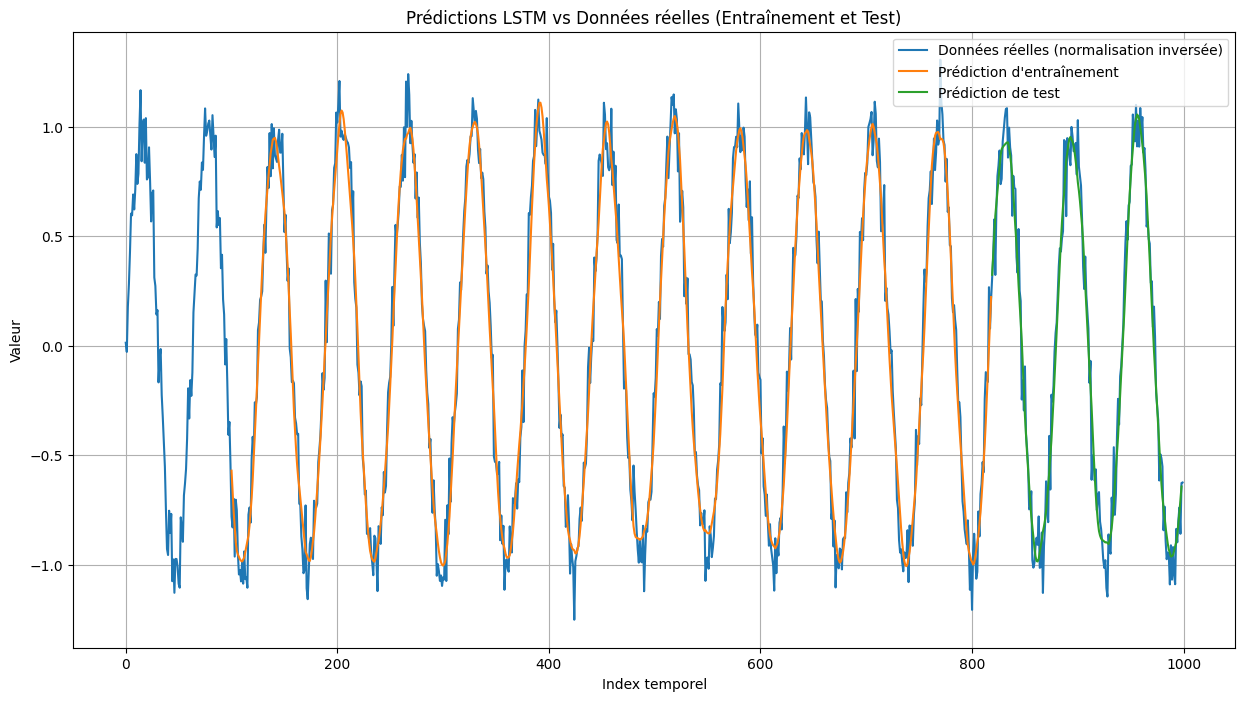

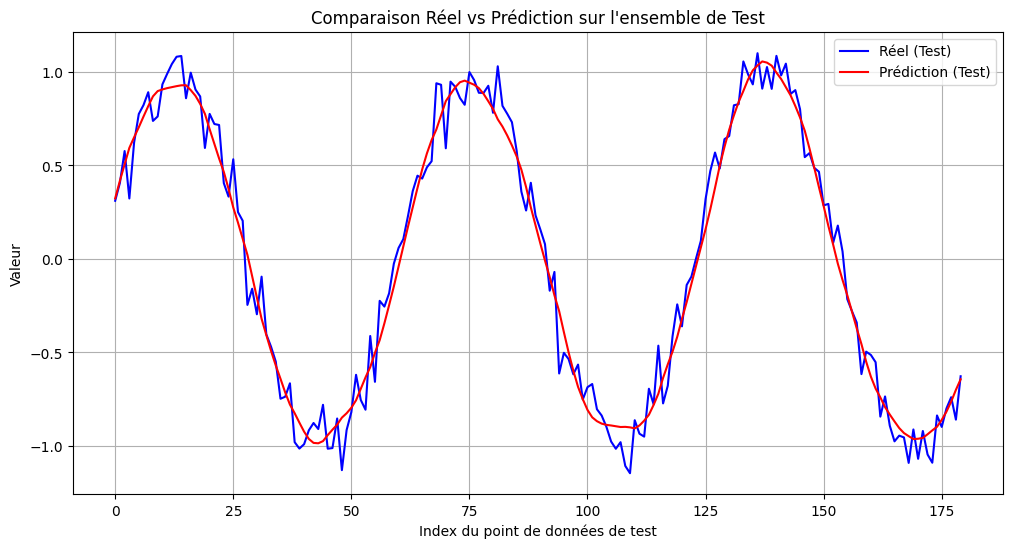


Analyse des résidus : Autocorrélation (ACF) et Autocorrélation partielle (PACF)


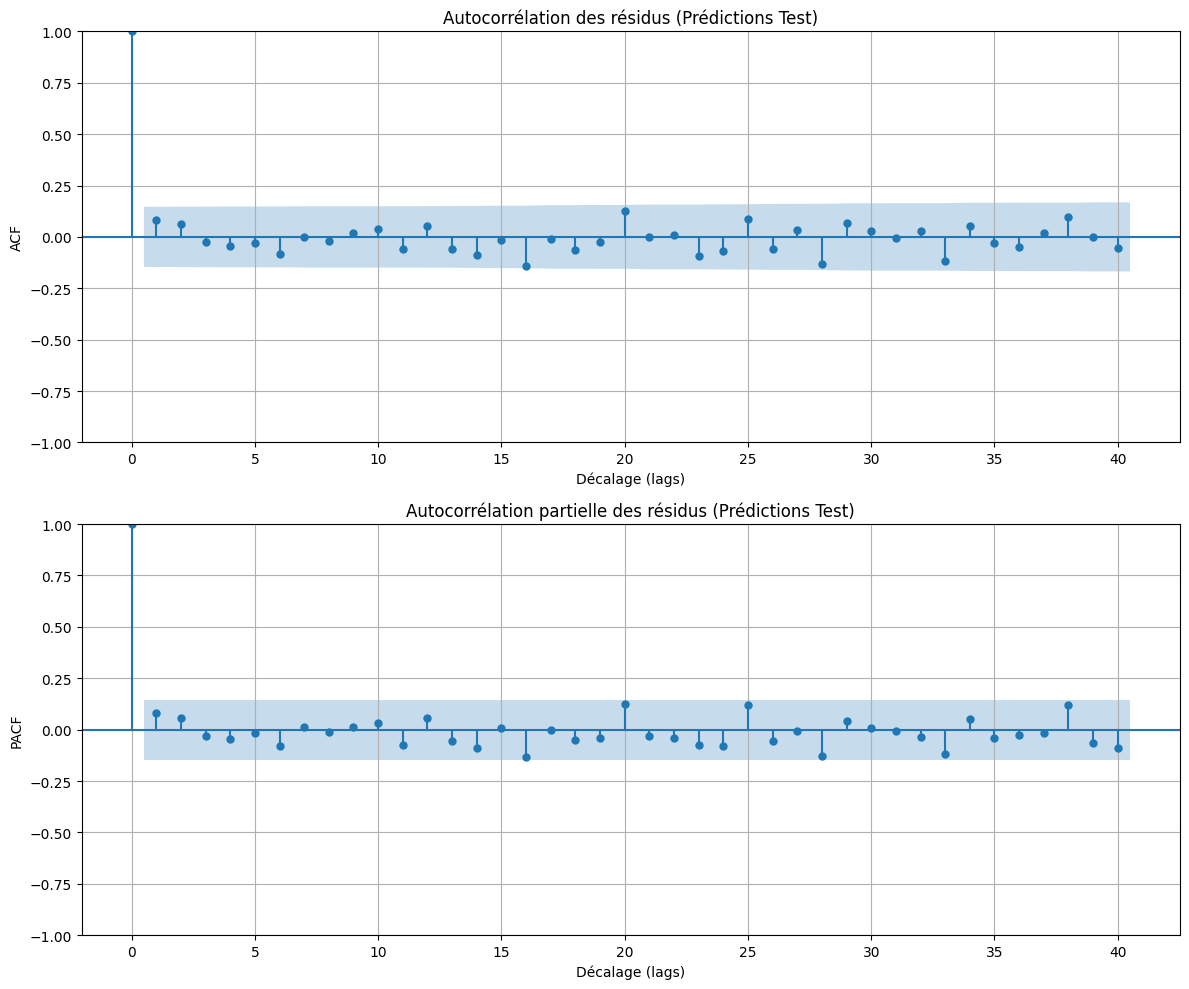


Fin de la Partie 6 : Application de LSTM


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Importation nécessaire

print("Début de la Partie 6 : Application de LSTM")

# --- 6.1 Préparation des données pour LSTM ---

# Création de données de série temporelle synthétiques
# Assurez-vous que 'data' est toujours un tableau 2D avant la normalisation
try:
    if 'df' not in locals() and 'df' not in globals():
        print("DataFrame 'df' non trouvé. Création de données synthétiques pour l'exemple.")
        synthetic_data_1d = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)
        df = pd.DataFrame(synthetic_data_1d, columns=['value'])
        data = synthetic_data_1d.reshape(-1, 1) # Redimensionner ici
        print("Données synthétiques créées.")
    else:
        print("Utilisation du DataFrame 'df' existant.")
        if 'value' not in df.columns:
            print("La colonne 'value' n'a pas été trouvée dans le DataFrame existant. Veuillez l'adapter ou renommer votre colonne de série temporelle.")
            synthetic_data_1d = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)
            df = pd.DataFrame(synthetic_data_1d, columns=['value'])
            data = synthetic_data_1d.reshape(-1, 1) # Redimensionner ici
            print("Données synthétiques utilisées pour l'exemple.")
        else:
            data = df['value'].values.reshape(-1, 1) # Déjà redimensionné ici

except NameError:
    print("DataFrame 'df' non défini. Création de données synthétiques pour l'exemple.")
    synthetic_data_1d = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)
    df = pd.DataFrame(synthetic_data_1d, columns=['value'])
    data = synthetic_data_1d.reshape(-1, 1) # Redimensionner ici
    print("Données synthétiques créées.")

# Normalisation des données
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Fonction pour créer des séquences
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Paramètre LSTM
time_step = 100
X, y = create_sequences(scaled_data, time_step)

# Mise en forme pour LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Division en train/test
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:]
y_train, y_test = y[0:train_size], y[train_size:]

print(f"Forme de X_train: {X_train.shape}")
print(f"Forme de y_train: {y_train.shape}")
print(f"Forme de X_test: {X_test.shape}")
print(f"Forme de y_test: {y_test.shape}")

# --- 6.2 Construction du modèle LSTM ---
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# --- 6.3 Entraînement ---
print("\nEntraînement du modèle LSTM...")
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)
print("Entraînement terminé.")

# Visualisation des pertes
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Perte d\'entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.title('Perte du modèle LSTM pendant l\'entraînement')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)
plt.show()

# --- 6.4 Prédictions ---
print("\nRéalisation de prédictions sur l'ensemble de test...")
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse la normalisation
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# --- 6.5 Évaluation ---
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
train_mae = mean_absolute_error(y_train_inv, train_predict)
print(f"\nRMSE (entraînement): {train_rmse:.4f}")
print(f"MAE (entraînement): {train_mae:.4f}")

test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
test_mae = mean_absolute_error(y_test_inv, test_predict)
print(f"RMSE (test): {test_mae:.4f}")

# Création des tableaux vides pour le tracé complet
look_back = time_step # 'look_back' correspond à 'time_step' dans votre code actuel

train_predict_plot = np.empty_like(scaled_data)
train_predict_plot[:, :] = np.nan
train_predict_plot[look_back:look_back + len(train_predict), :] = train_predict

test_predict_plot = np.empty_like(scaled_data)
test_predict_plot[:, :] = np.nan
start_test = look_back + len(train_predict)
end_test = start_test + len(test_predict)
test_predict_plot[start_test:end_test, :] = test_predict

# Tracé global (comparaison complète entraînement et test)
plt.figure(figsize=(15, 8))
plt.plot(scaler.inverse_transform(scaled_data), label='Données réelles (normalisation inversée)')
plt.plot(train_predict_plot, label='Prédiction d\'entraînement')
plt.plot(test_predict_plot, label='Prédiction de test')
plt.title('Prédictions LSTM vs Données réelles (Entraînement et Test)')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True)
plt.show()

# --- NOUVEAU GRAPHIQUE : Comparaison Réel vs Prédiction (Uniquement sur l'ensemble de TEST) ---
# Ce graphique est similaire à l'image que vous avez fournie (image_7cdd8a.jpg)
plt.figure(figsize=(12, 6))
# Pour que l'axe X représente les points de données de test, nous utilisons un range d'indices
# ou si votre df original a un index temporel, il faudrait le récupérer pour y_test_inv
plt.plot(range(len(y_test_inv)), y_test_inv, label='Réel (Test)', color='blue')
plt.plot(range(len(test_predict)), test_predict, label='Prédiction (Test)', color='red')
plt.title('Comparaison Réel vs Prédiction sur l\'ensemble de Test')
plt.xlabel('Index du point de données de test')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True)
plt.show()


# --- Nouveaux graphiques : ACF et PACF des résidus ---
print("\nAnalyse des résidus : Autocorrélation (ACF) et Autocorrélation partielle (PACF)")

# Calcul des résidus (différence entre les valeurs réelles et prédites)
residuals = y_test_inv.flatten() - test_predict.flatten()

# Déterminer un nombre de décalages (lags) approprié
max_lags = min(len(residuals) // 2 - 1 if len(residuals) // 2 - 1 > 0 else 1, 40)

if max_lags < 1:
    print(f"Attention: Pas assez de points pour calculer l'ACF/PACF de manière significative (résidus: {len(residuals)}).")
    print("Assurez-vous que la taille de votre ensemble de test est suffisante.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # Graphique ACF des résidus
    plot_acf(residuals, lags=max_lags, ax=axes[0], title='Autocorrélation des résidus (Prédictions Test)')
    axes[0].set_xlabel('Décalage (lags)')
    axes[0].set_ylabel('ACF')
    axes[0].grid(True)

    # Graphique PACF des résidus
    plot_pacf(residuals, lags=max_lags, ax=axes[1], title='Autocorrélation partielle des résidus (Prédictions Test)')
    axes[1].set_xlabel('Décalage (lags)')
    axes[1].set_ylabel('PACF')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("\nFin de la Partie 6 : Application de LSTM")